# Agents

The `Agent` class is a container for a bunch of different configs and other objects that the Responses API uses to call the LLM. The main work is done in the `Runner.run()` function.

```
run() -> _run_single_turn() -> _get_new_response() -> model.get_response() -> OpenAIResponsesModel::get_response() -> _fetch_response() -> client.responses.create()
```

The AgentSDK does a pretty decent job of adding all the LLM calls to the debug logs.

In [1]:
from agents import Agent, InputGuardrail, GuardrailFunctionOutput, Runner
from pydantic import BaseModel
import asyncio
from agents.extensions.visualization import draw_graph

In [2]:
class HomeworkOutput(BaseModel):
    is_homework: bool
    reasoning: str

In [3]:
guardrail_agent = Agent(
    name="Guardrail Check",
    instructions="Check if the user is asking about homework.",
    output_type=HomeworkOutput,
)

In [4]:
math_tutor_agent = Agent(
    name="Math Tutor",
    handoff_description="Specialist agent for math questions.",
    instructions="You provide help with amth problems. Explain your reasoning at each step and include examples.",
)

In [5]:
history_tutor_agent = Agent(
    name="History Tutor",
    handoff_description="Specialist agent for historical questions.",
    instructions="You provide assistance queries. Explain important events and context clearly.",
)

In [6]:
async def homework_guardrail(ctx, agent, input_data):
    result = await Runner.run(guardrail_agent, input_data, context=ctx.context)
    final_output = result.final_output_as(HomeworkOutput)
    return GuardrailFunctionOutput(
        output_info=final_output, tripwire_triggered=not final_output.is_homework
    )

In [7]:
triage_agent = Agent(
    name="Triage Agent",
    instructions="You determine which agent to use based on the user's homework.",
    handoffs=[history_tutor_agent, math_tutor_agent],
    input_guardrails=[InputGuardrail(guardrail_function=homework_guardrail)],
)

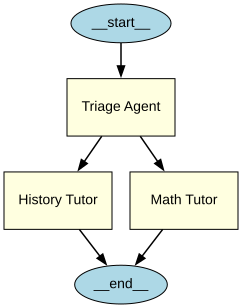

In [9]:
draw_graph(triage_agent)

In [ ]:
result = await Runner.run(
    triage_agent, "Who was the first president of the United States?"
)
result

```python
RunResult(
    input='Who was the first president of the United States?', 
    new_items=[
        HandoffCallItem(
            agent=Agent(name='Triage Agent',...), 
            raw_item=ResponseFunctionToolCall(
                arguments='{}', 
                call_id='call_ocWEOzmtE6zmcNdL5bz9J8Va', 
                name='transfer_to_history_tutor', 
                type='function_call', 
                id='fc_68014f0910fc8191b54cb2cd6aabd4a303a675d9fdf775bf', 
                status='completed'
            ), 
            type='handoff_call_item'
        ), 
        HandoffOutputItem(
            agent=Agent(name='Triage Agent', ...), 
            raw_item={
                'call_id': 'call_ocWEOzmtE6zmcNdL5bz9J8Va', 
                'output': "{'assistant': 'History Tutor'}", 'type': 'function_call_output'
            }, 
            source_agent=Agent(name='Triage Agent', ...), 
            target_agent=Agent(name='History Tutor',...), 
            type='handoff_output_item'
        ), 
        MessageOutputItem(
            agent=Agent(name='History Tutor'...), 
            raw_item=ResponseOutputMessage(
                id='msg_68014f0a7d9081918af72d5e4276d61e03a675d9fdf775bf', 
                content=[
                    ResponseOutputText(
                        annotations=[], 
                        text='The first president of the United States was George Washington. He served from 1789 to 1797 and is often referred to as the "Father of His Country." Washington played a crucial role in leading the American colonies to victory over Britain during the American Revolutionary War and later presided over the convention that drafted the U.S. Constitution. As president, he set many key precedents for the new government.', 
                        type='output_text'
                    )
                ], 
                role='assistant', 
                status='completed', 
                type='message'
            ), 
            type='message_output_item'
        )
    ], 
    raw_responses=[
        ModelResponse(
            output=[
                ResponseFunctionToolCall(
                    arguments='{}', 
                    call_id='call_ocWEOzmtE6zmcNdL5bz9J8Va', 
                    name='transfer_to_history_tutor', 
                    type='function_call', 
                    id='fc_68014f0910fc8191b54cb2cd6aabd4a303a675d9fdf775bf', 
                    status='completed'
                )
            ], 
            usage=Usage(
                requests=1, 
                input_tokens=101, 
                output_tokens=14, 
                total_tokens=115
            ), 
            referenceable_id='resp_68014f07eb808191b1cf35d5b15e7da003a675d9fdf775bf'
        ), 
        ModelResponse(
            output=[
                ResponseOutputMessage(
                    id='msg_68014f0a7d9081918af72d5e4276d61e03a675d9fdf775bf', 
                    content=[
                        ResponseOutputText(
                            annotations=[], 
                            text='The first president of the United States was George Washington. He served from 1789 to 1797 and is often referred to as the "Father of His Country." Washington played a crucial role in leading the American colonies to victory over Britain during the American Revolutionary War and later presided over the convention that drafted the U.S. Constitution. As president, he set many key precedents for the new government.', 
                            type='output_text'
                        )
                    ], 
                    role='assistant', 
                    status='completed', 
                    type='message'
                )
            ], 
            usage=Usage(
                requests=1, 
                input_tokens=65, 
                output_tokens=83, 
                total_tokens=148
            ), 
            referenceable_id='resp_68014f09e96c8191ae6cc1409fb8ec5603a675d9fdf775bf'
        )
    ], 
    final_output='The first president of the United States was George Washington. He served from 1789 to 1797 and is often referred to as the "Father of His Country." Washington played a crucial role in leading the American colonies to victory over Britain during the American Revolutionary War and later presided over the convention that drafted the U.S. Constitution. As president, he set many key precedents for the new government.', 
    input_guardrail_results=[
        InputGuardrailResult(
            guardrail=InputGuardrail(guardrail_function=<function homework_guardrail at 0x7bd8b42d0400>, name=None), output=GuardrailFunctionOutput(
                output_info=HomeworkOutput(
                    is_homework=True, 
                    reasoning='The question asks for a basic historical fact that is often a common type of homework assignment in history or social studies classes.'
                ), 
                tripwire_triggered=False
            )
        )
    ], 
    output_guardrail_results=[], 
    _last_agent=Agent(name='History Tutor', ...)
)
```

In [ ]:
result.final_output

In [ ]:
try:
    result = await Runner.run(triage_agent, "What is life?")
except Exception as err:
    print(err)